In [1]:
from datadlc import DataDLC
from plotting import Plotting
from dataneuron import DataNeuron
from mergeddata import MergedData

#### 1: DataDLC

In [2]:
import pandas as pd
def transform_to_derivative(df: pd.DataFrame) -> pd.DataFrame:

    # Ensure the DataFrame has an even number of columns (x and y pairs)
    if df.shape[1] % 2 != 0:
        raise ValueError("The DataFrame must have an even number of columns (x and y pairs).")

    # Calculate the derivative (difference between consecutive rows)
    derivative_df = df.diff().abs().iloc[1:]  # Use `.diff()` and drop the first row (NaN)
    
    # Replace columns above a certain value with 0
    #threshold = 75  # Define your threshold here
    #derivative_df[derivative_df > threshold] = 0

    # Rename columns to indicate they are derivatives
    derivative_df.columns = [f"{col}_derivative" for col in df.columns]

    return derivative_df

In [3]:
data_dlc = DataDLC(
    r"C:\Python Programming\LIU\projects\Img_3740-3741_labeled\IMG_3741_convertedDLC_Resnet50_td_res50_2Mar13shuffle1_detector_200_snapshot_075.h5"
    )

<Axes: title={'center': 'Monofilament Derivative Before Imputing Outliers'}, xlabel='Frame', ylabel='Derivative'>

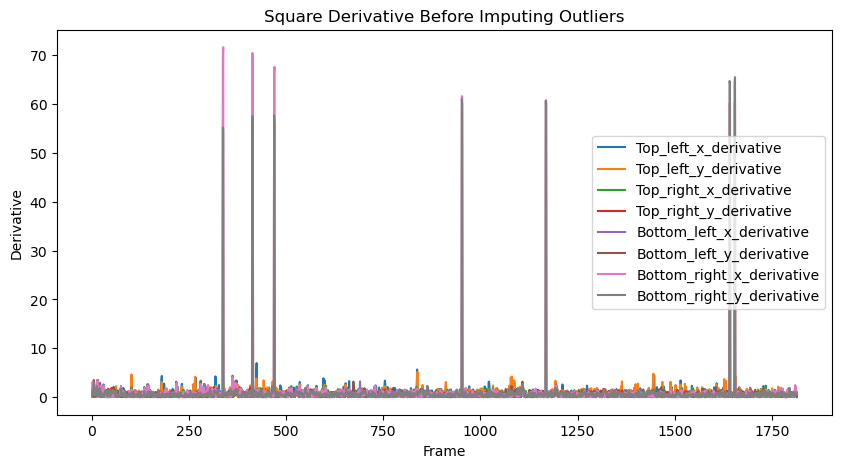

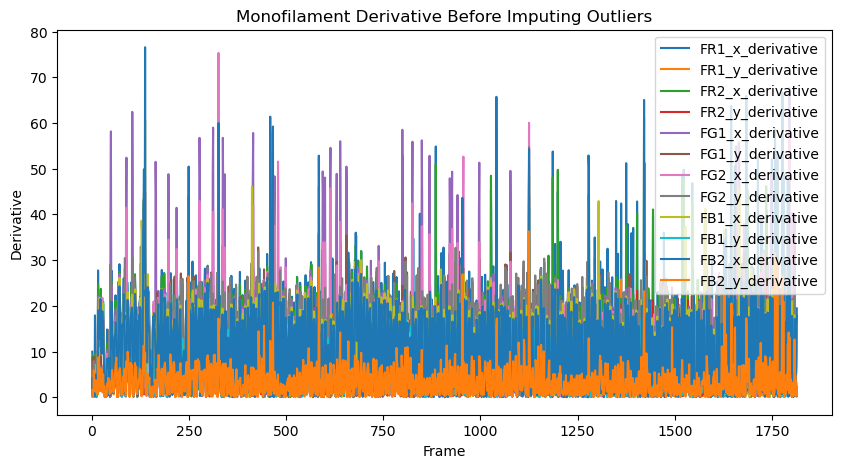

In [4]:
df_square_deriv = transform_to_derivative(data_dlc.df_square)
df_monofil_deriv = transform_to_derivative(data_dlc.df_monofil)
df_square_deriv.plot(title="Square Derivative Before Imputing Outliers",
                     xlabel="Frame", ylabel="Derivative", legend=True,
                     figsize=(10, 5))
df_monofil_deriv.plot(title="Monofilament Derivative Before Imputing Outliers",
                     xlabel="Frame", ylabel="Derivative", legend=True,
                     figsize=(10, 5))

In [5]:
data_dlc.impute_outliers(std_threshold=6,
                         square=True, filament=False)

In [6]:
data_dlc.impute_outliers(std_threshold=6,
                         square=False, filament=True)

<Axes: title={'center': 'Monofilament Derivative After Imputing Outliers'}, xlabel='Frame', ylabel='Derivative'>

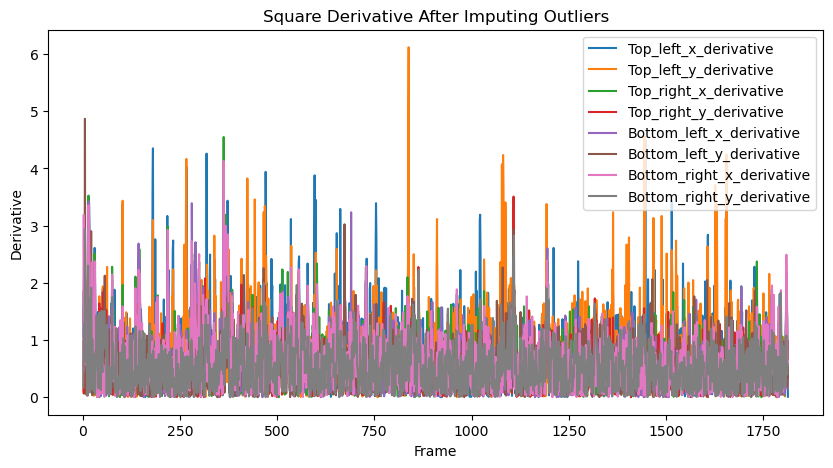

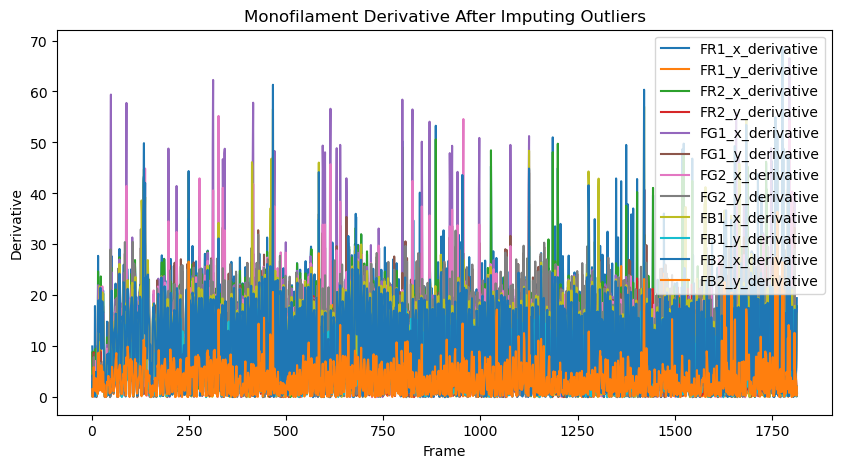

In [7]:
df_square_deriv = transform_to_derivative(data_dlc.df_square)
df_monofil_deriv = transform_to_derivative(data_dlc.df_monofil)
df_square_deriv.plot(title="Square Derivative After Imputing Outliers",
                     xlabel="Frame", ylabel="Derivative", legend=True,
                     figsize=(10, 5))
df_monofil_deriv.plot(title="Monofilament Derivative After Imputing Outliers",
                     xlabel="Frame", ylabel="Derivative", legend=True,
                     figsize=(10, 5))

In [8]:
data_dlc.get_bending_coefficients()

0       0.000227
1       0.000050
2       0.000277
3       0.000047
4       0.000353
          ...   
1810    0.003057
1811    0.002747
1812    0.003164
1813    0.002946
1814    0.003448
Name: Bending_Coefficient, Length: 1815, dtype: float64

In [9]:
data_dlc.apply_homography()

,tf_FR1_x,tf_FR1_y,tf_FR2_x,tf_FR2_y,tf_FG1_x,tf_FG1_y,tf_FG2_x,tf_FG2_y,tf_FB1_x,tf_FB1_y,tf_FB2_x,tf_FB2_y
0,-502.276703,350.406860,-485.154388,341.246613,-455.519775,314.174988,-441.015076,309.238098,-389.624481,278.841370,-356.049622,253.011276
1,-530.560303,362.199432,-502.075958,345.936218,-472.061676,320.555695,-454.746460,313.261078,-404.452667,285.099945,-367.724670,254.415726
2,-550.495056,360.772705,-523.529480,346.861877,-486.019897,317.264862,-469.522888,307.600555,-414.053101,277.325989,-379.679016,254.826080
3,-529.686707,348.445007,-502.044342,336.062134,-470.405304,310.518799,-452.681732,303.134613,-401.269897,272.620605,-368.648529,252.309158
4,-525.069580,342.168518,-496.929047,329.635681,-464.459503,305.556458,-446.796539,297.059906,-398.516022,272.792450,-366.313568,257.711914
...,...,...,...,...,...,...,...,...,...,...,...,...
1810,-17.476425,510.809235,-1.036262,440.398010,20.573730,368.402557,35.757511,319.734955,73.740677,233.621399,98.101158,188.881607
1811,-29.193235,536.314148,-10.705651,461.484589,10.476730,389.641602,28.662741,344.094177,66.582016,254.742233,91.734558,208.197998
1812,-13.006887,532.223999,3.073919,457.618713,23.004454,386.675385,39.146538,339.126678,76.183311,250.744583,100.379608,206.507980
1813,11.267023,513.968872,28.565615,436.871399,47.841702,363.294220,63.318111,316.622742,99.062462,226.099579,123.215736,180.187668


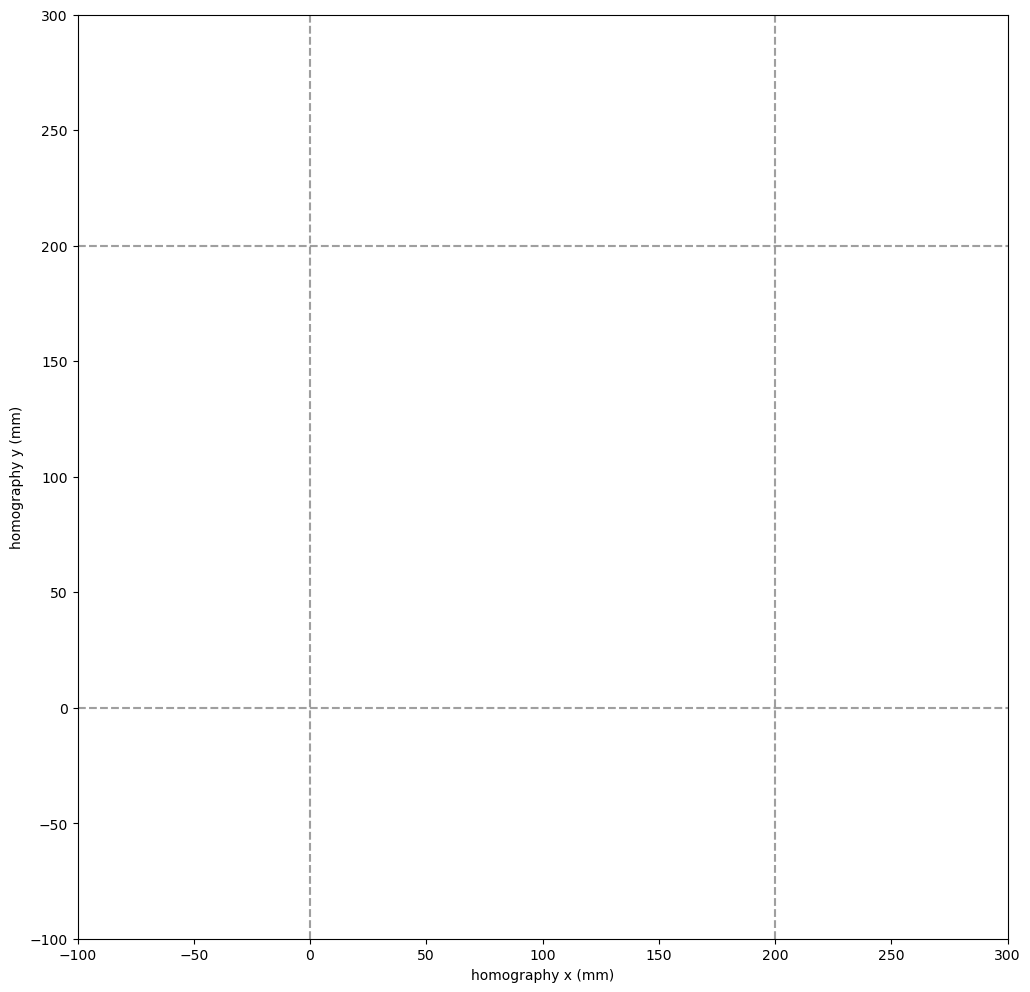

In [10]:
Plotting.plot_homography_animated(data_dlc.homography_points,
                                  data_dlc.df_transformed_monofil,
                                  "homography_animation_3741.mp4")

#### 2: DataNeuron

In [11]:
data_neuron = DataNeuron(
    r"C:\Python Programming\LIU\Data\nerve accel data\20250306_MP_018_radial_2Sel_unit_6_RF_mapp_2_3741.xlsx",
    120000
    )

c:\Python Programming\LIU\RF_mapping\RF_mapping\post_processing\dataneuron.py:67: RuntimeWarning: divide by zero encountered in scalar divide
  current_freq = 1 / np.mean(time_diffs).round()
c:\Python Programming\LIU\RF_mapping\RF_mapping\post_processing\dataneuron.py:88: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  filled_df['IFF'].fillna(method='ffill', inplace=True)
c:\Python Programming\LIU\RF_mapping\RF_mapping\post_processing\dataneuron.py:88: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a 

c:\Python Programming\LIU\RF_mapping\RF_mapping\post_processing\plotting.py:65: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend(loc='upper right', bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)


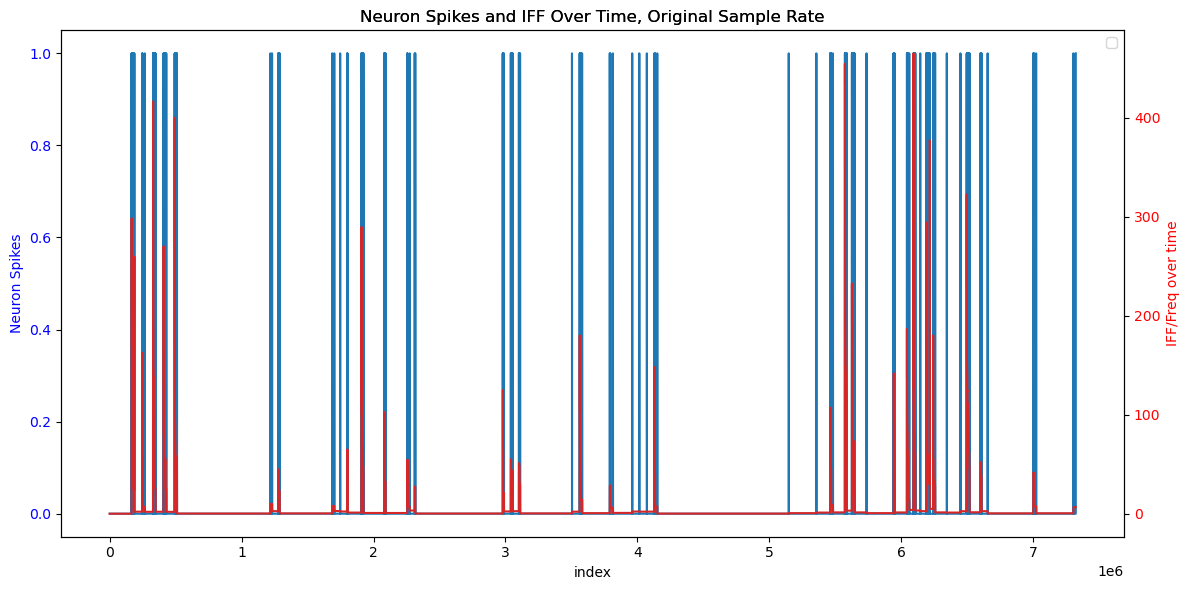

In [12]:
columns = data_neuron.df.columns

Plotting.plot_lines(data_neuron.df,
                    columns[1:],
                    xlabel="index",
                    ylabel_1="Neuron Spikes",
                    ylabel_2="IFF/Freq over time",
                    title="Neuron Spikes and IFF Over Time, Original Sample Rate")

In [13]:
data_neuron.downsample(30) 

4000


,IFF,Spikes
0,0.000000,0.0
1,0.000000,0.0
2,0.000000,0.0
3,0.000000,0.0
4,0.000000,0.0
...,...,...
1826,0.424367,0.0
1827,6.688963,1.0
1828,6.688963,0.0
1829,6.688963,0.0


c:\Python Programming\LIU\RF_mapping\RF_mapping\post_processing\plotting.py:65: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend(loc='upper right', bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)


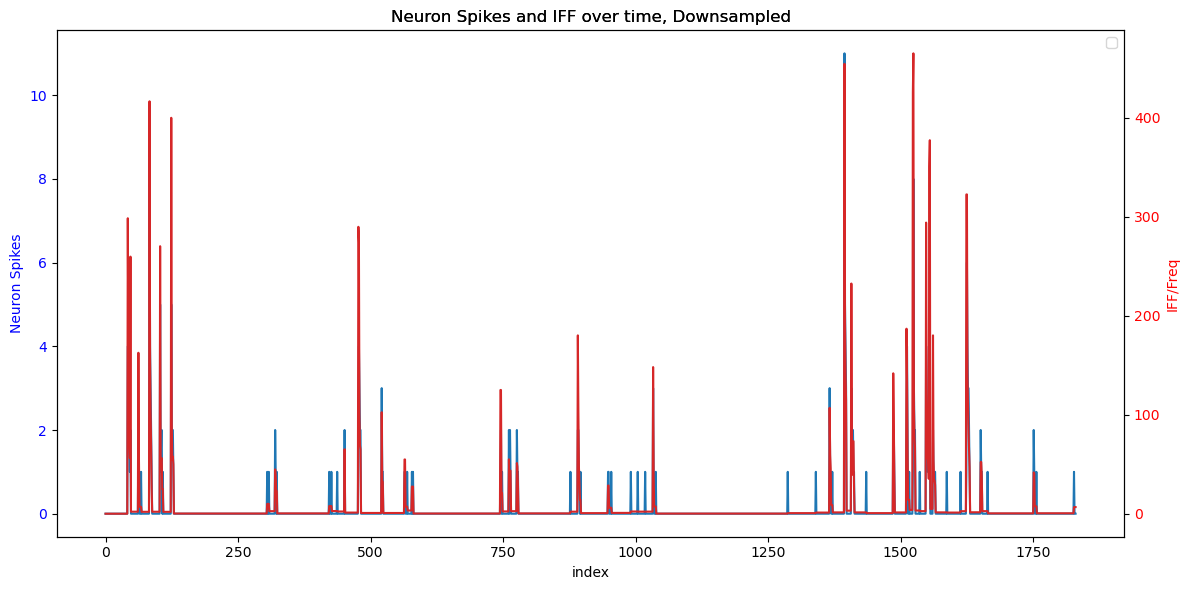

In [14]:
Plotting.plot_lines(data_neuron.downsampled_df,
                    columns[1:],
                    "index", "Neuron Spikes", "IFF/Freq",
                    "Neuron Spikes and IFF over time, Downsampled")

#### 3: MergeData

In [15]:
full_data = MergedData(data_dlc, data_neuron)

c:\Python Programming\LIU\RF_mapping\RF_mapping\post_processing\mergeddata.py:38: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_neuron['Spikes_Filled'][gap_start:i] = 1
c:\Python Programming\LIU\RF_mapping\RF_mapping\post_processing\merge

c:\Python Programming\LIU\RF_mapping\RF_mapping\post_processing\plotting.py:65: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend(loc='upper right', bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)


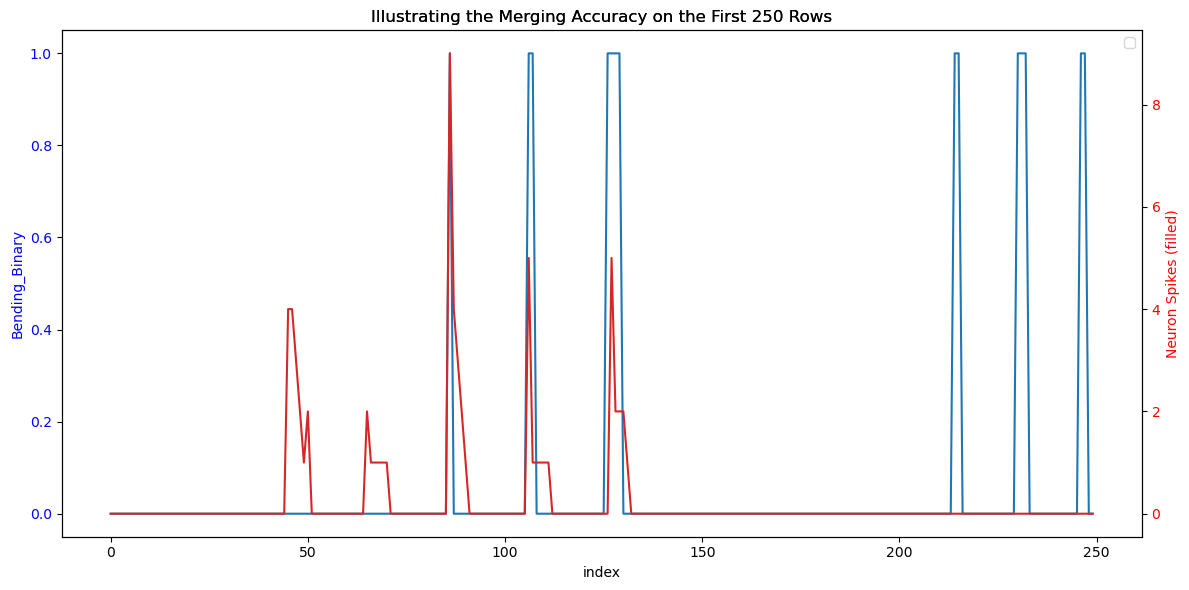

In [16]:
# Show the accuracy of the merging on the first 250 rows, specifically
# the first 5 bundles of 'activation'
Plotting.plot_lines(full_data.df_merged[:250],
                    ["Bending_Binary","Spikes_Filled"],
                    "index", "Bending_Binary", "Neuron Spikes (filled)",
                    "Illustrating the Merging Accuracy on the First 250 Rows",)

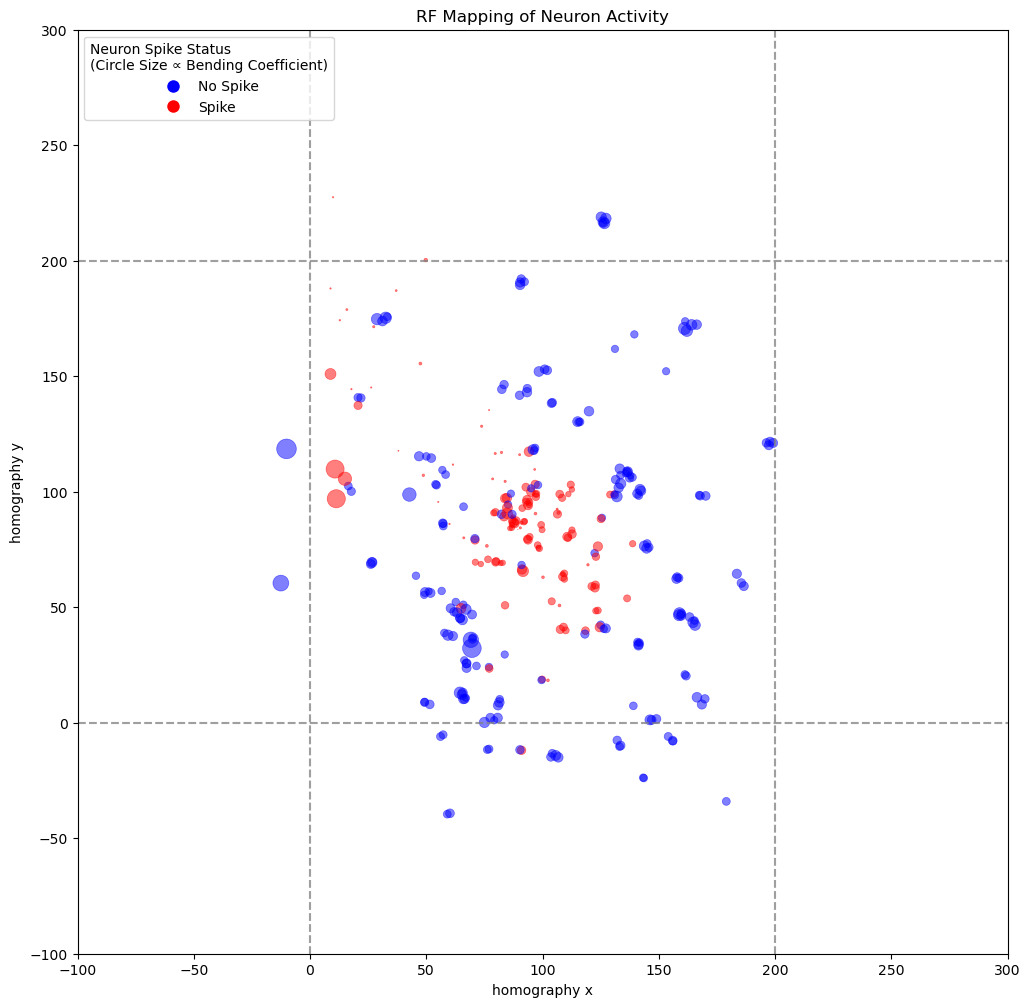

In [17]:
Plotting.plot_rf_mapping(full_data,
                         "tf_FB2_x", "tf_FB2_y",
                         "Bending_Coefficient",
                         "Spikes",
                         full_data.dlc.homography_points)

c:\Python Programming\LIU\RF_mapping\RF_mapping\post_processing\plotting.py:217: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["scaled_size"] = scaler.fit_transform(df[[bending_col]])


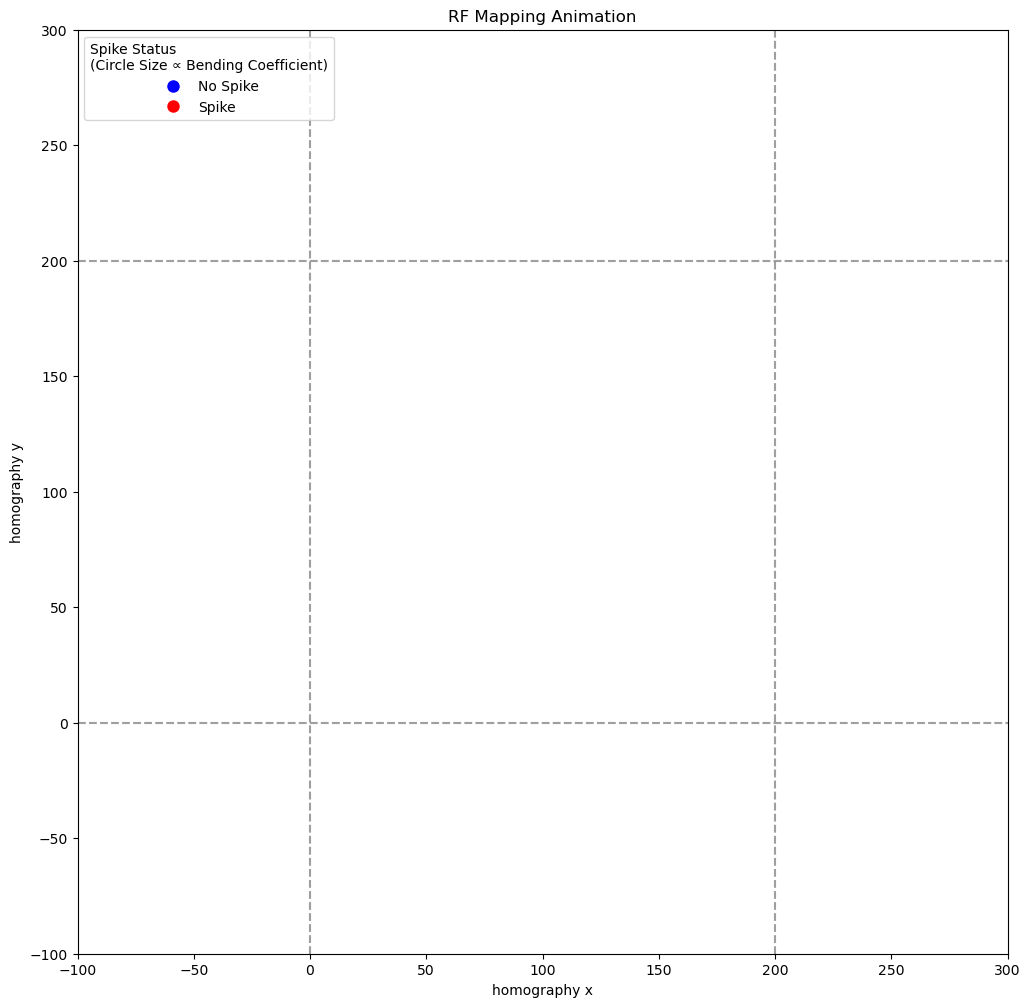

c:\Python Programming\LIU\RF_mapping\RF_mapping\post_processing\plotting.py:234: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  circle = plt.Circle((x, y), size, color=color, alpha=0.5, edgecolor="k", linewidth=0.5)


In [18]:
Plotting.plot_rf_mapping_animated(full_data,
                                  "tf_FB2_x", "tf_FB2_y",
                                  "Bending_Coefficient",
                                  "Spikes",
                                  full_data.dlc.homography_points,
                                  "rf_mapping_animation_3741.mp4")

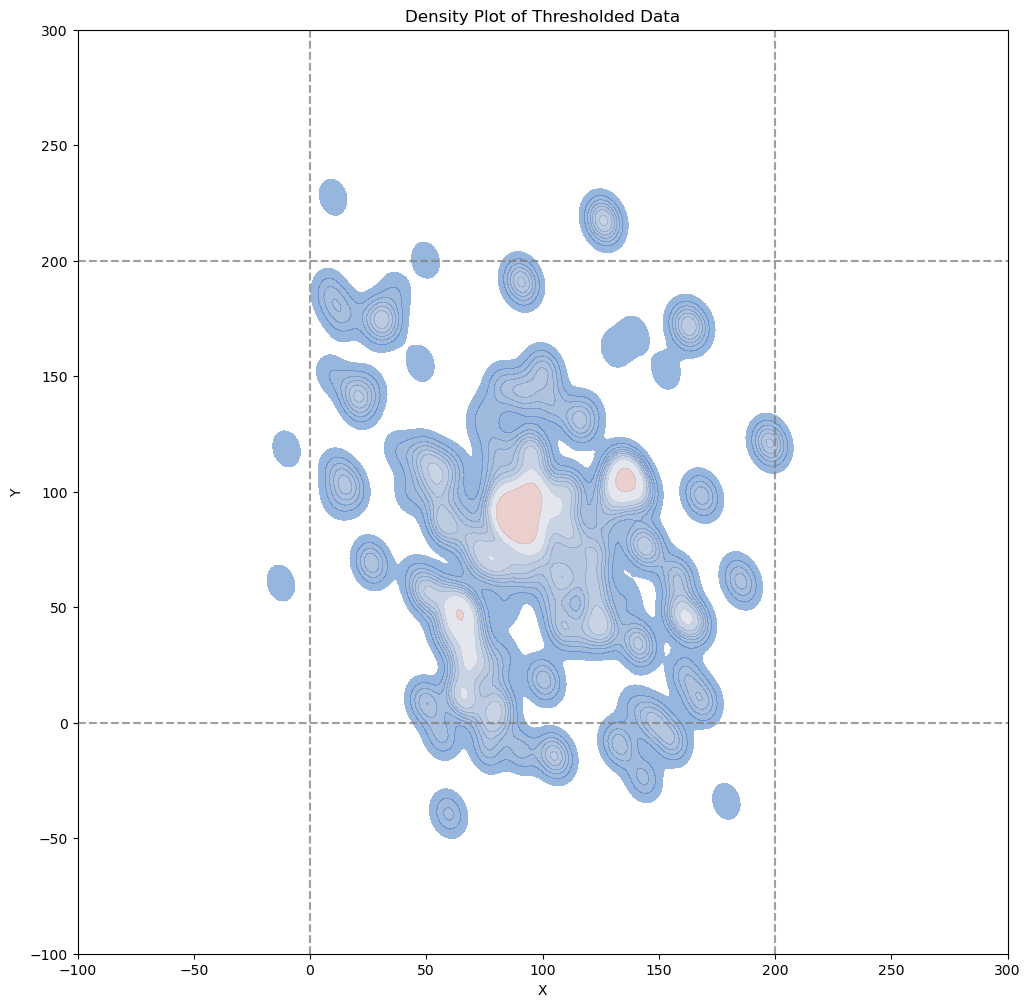

(<Figure size 1200x1200 with 1 Axes>,
 <Axes: title={'center': 'Density Plot of Thresholded Data'}, xlabel='X', ylabel='Y'>)

In [19]:
Plotting.plot_kde_scatter(full_data,
                          "tf_FB2_x", "tf_FB2_y",
                          full_data.dlc.homography_points,
                          size="IFF",
                          title="Density Plot of Thresholded Data",
                          kde=True,
                          scatter=False)

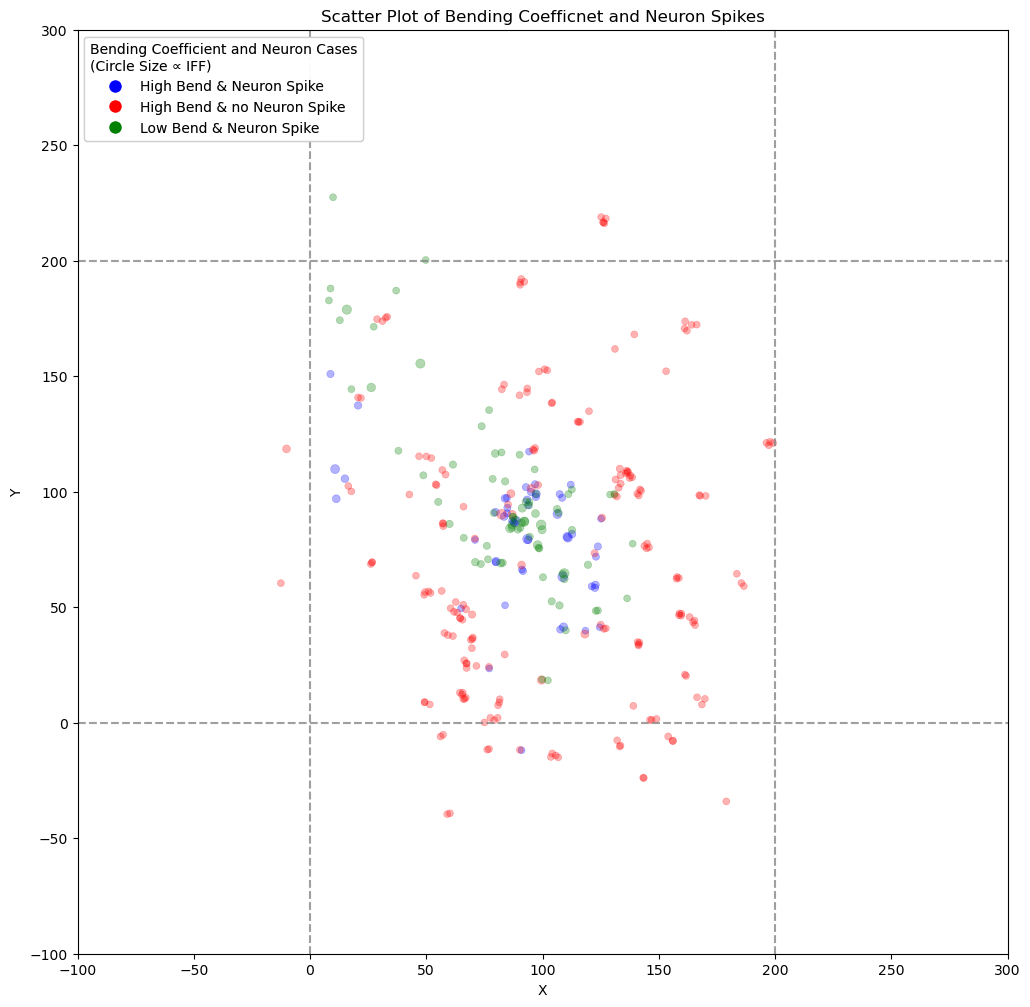

(<Figure size 1200x1200 with 1 Axes>,
 <Axes: title={'center': 'Scatter Plot of Bending Coefficnet and Neuron Spikes'}, xlabel='X', ylabel='Y'>)

In [20]:
Plotting.plot_kde_scatter(full_data,
                          "tf_FB2_x", "tf_FB2_y",
                          full_data.dlc.homography_points,
                          size="IFF",
                          title="Scatter Plot of Bending Coefficnet and Neuron Spikes",
                          kde=False,
                          scatter=True)

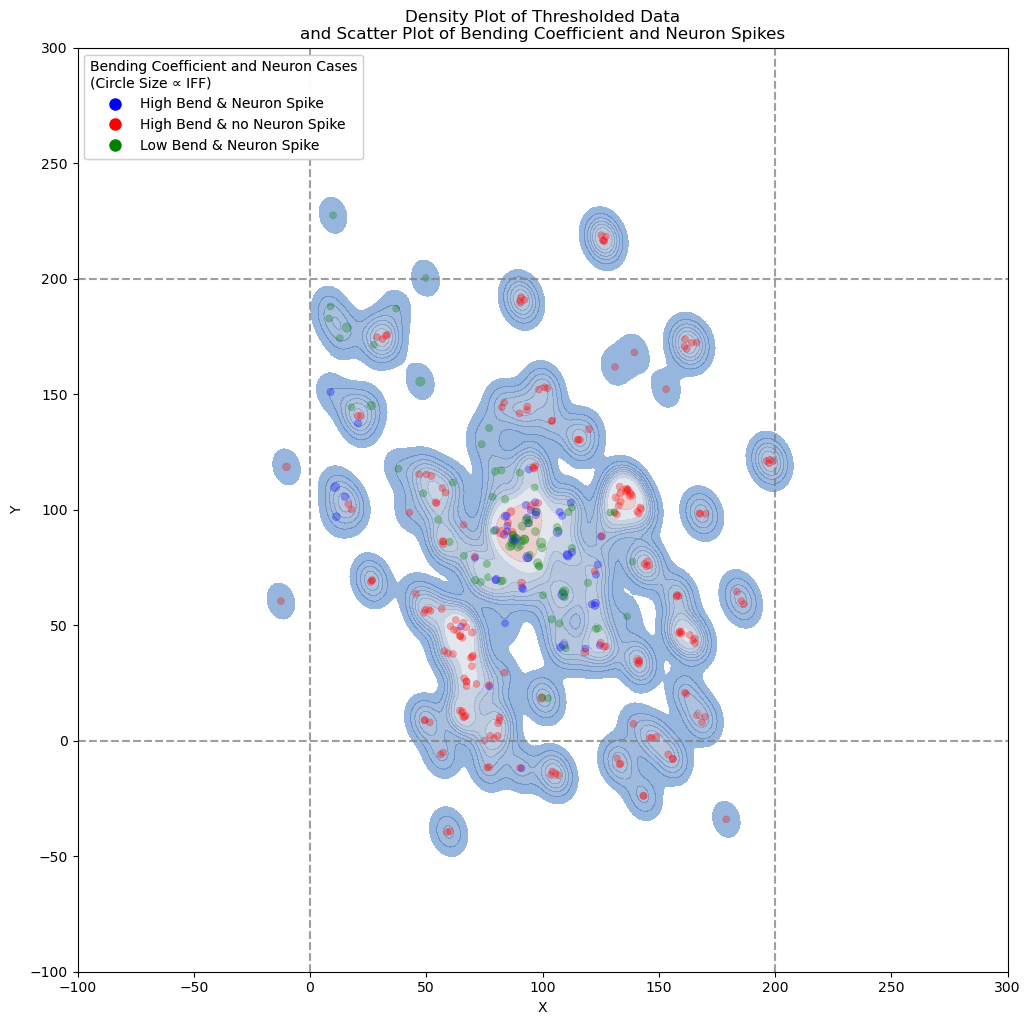

(<Figure size 1200x1200 with 1 Axes>,
 <Axes: title={'center': 'Density Plot of Thresholded Data\nand Scatter Plot of Bending Coefficient and Neuron Spikes'}, xlabel='X', ylabel='Y'>)

In [21]:
Plotting.plot_kde_scatter(full_data,
                          "tf_FB2_x", "tf_FB2_y",
                          full_data.dlc.homography_points,
                          size="IFF",
                          title="Density Plot of Thresholded Data" +
                                "\nand Scatter Plot of Bending Coefficient and Neuron Spikes",
                          kde=True,
                          scatter=True)

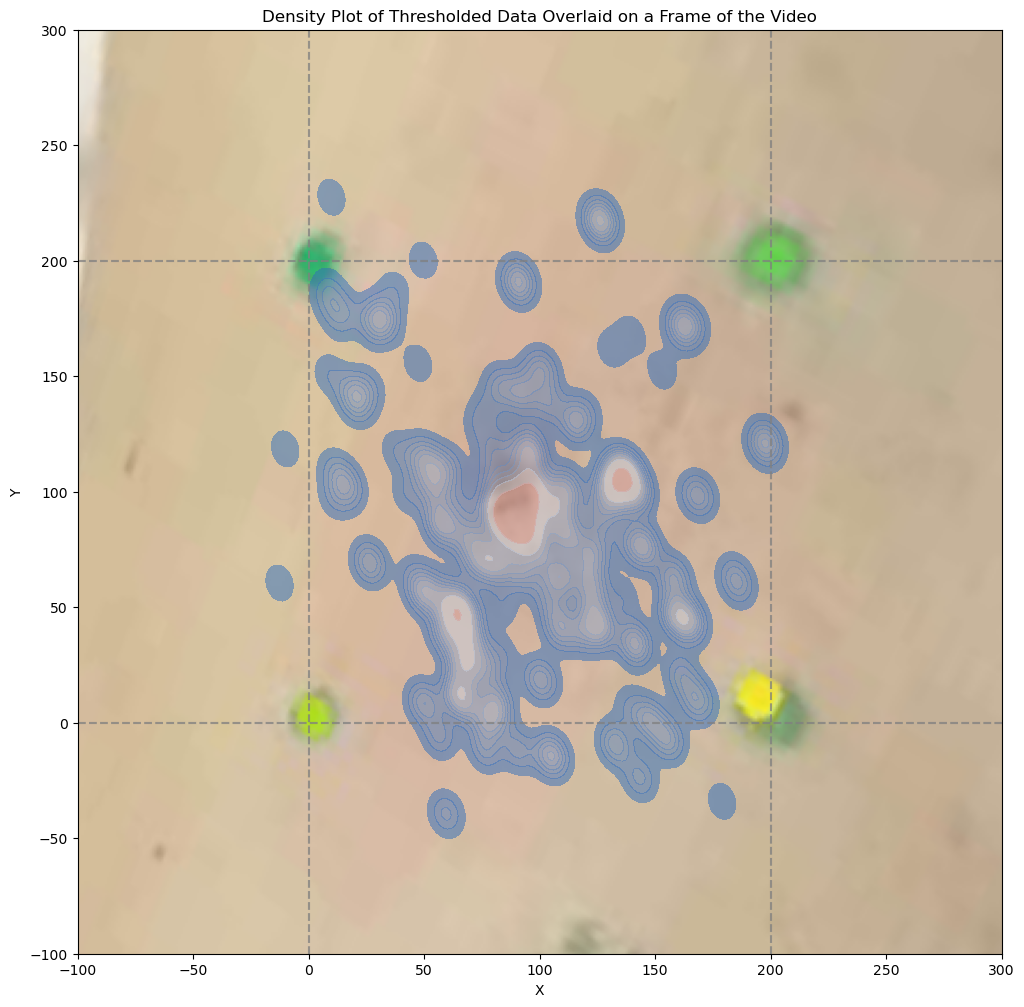

(<Figure size 1200x1200 with 1 Axes>,
 <Axes: title={'center': 'Density Plot of Thresholded Data Overlaid on a Frame of the Video'}, xlabel='X', ylabel='Y'>)

In [22]:
index_frame = 5
video_path = r"C:\Python Programming\LIU\projects\Img_3740-3741_labeled\IMG_3741_convertedDLC_Resnet50_td_res_3Mar18shuffle1_detector_200_snapshot_075_p50_labeled.mp4"
Plotting.plot_kde_scatter(full_data,
                          "tf_FB2_x", "tf_FB2_y",
                          full_data.dlc.homography_points,
                          size="IFF",
                          title="Density Plot of Thresholded Data Overlaid on a Frame of the Video",
                          kde=True,
                          scatter=False,
                          # inputs for selecting a specific frame as background
                          frame=True,
                          video_path=video_path,
                          index=index_frame)

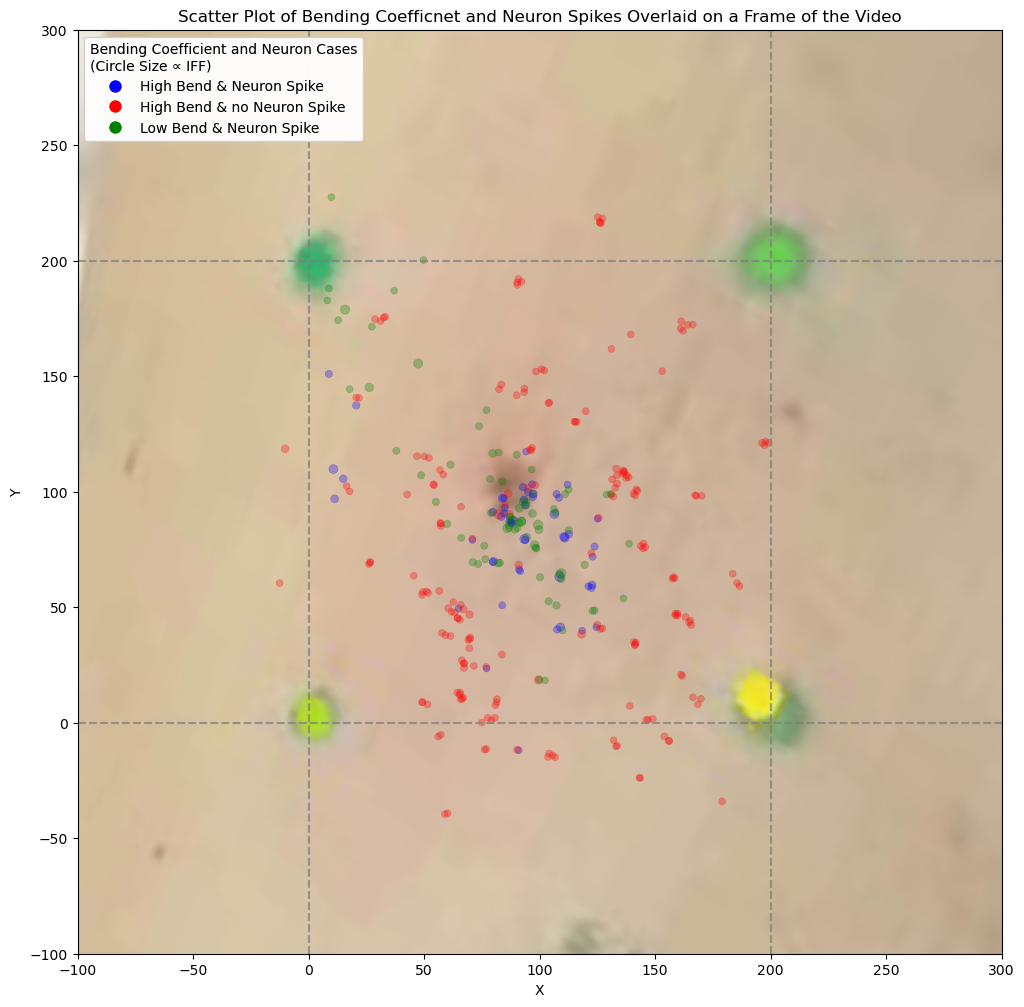

(<Figure size 1200x1200 with 1 Axes>,
 <Axes: title={'center': 'Scatter Plot of Bending Coefficnet and Neuron Spikes Overlaid on a Frame of the Video'}, xlabel='X', ylabel='Y'>)

In [23]:
Plotting.plot_kde_scatter(full_data,
                          "tf_FB2_x", "tf_FB2_y",
                          full_data.dlc.homography_points,
                          size="IFF",
                          title="Scatter Plot of Bending Coefficnet and Neuron Spikes Overlaid on a Frame of the Video",
                          kde=False,
                          scatter=True,
                          # inputs for selecting a specific frame as background
                          frame=True,
                          video_path=video_path,
                          index=index_frame)

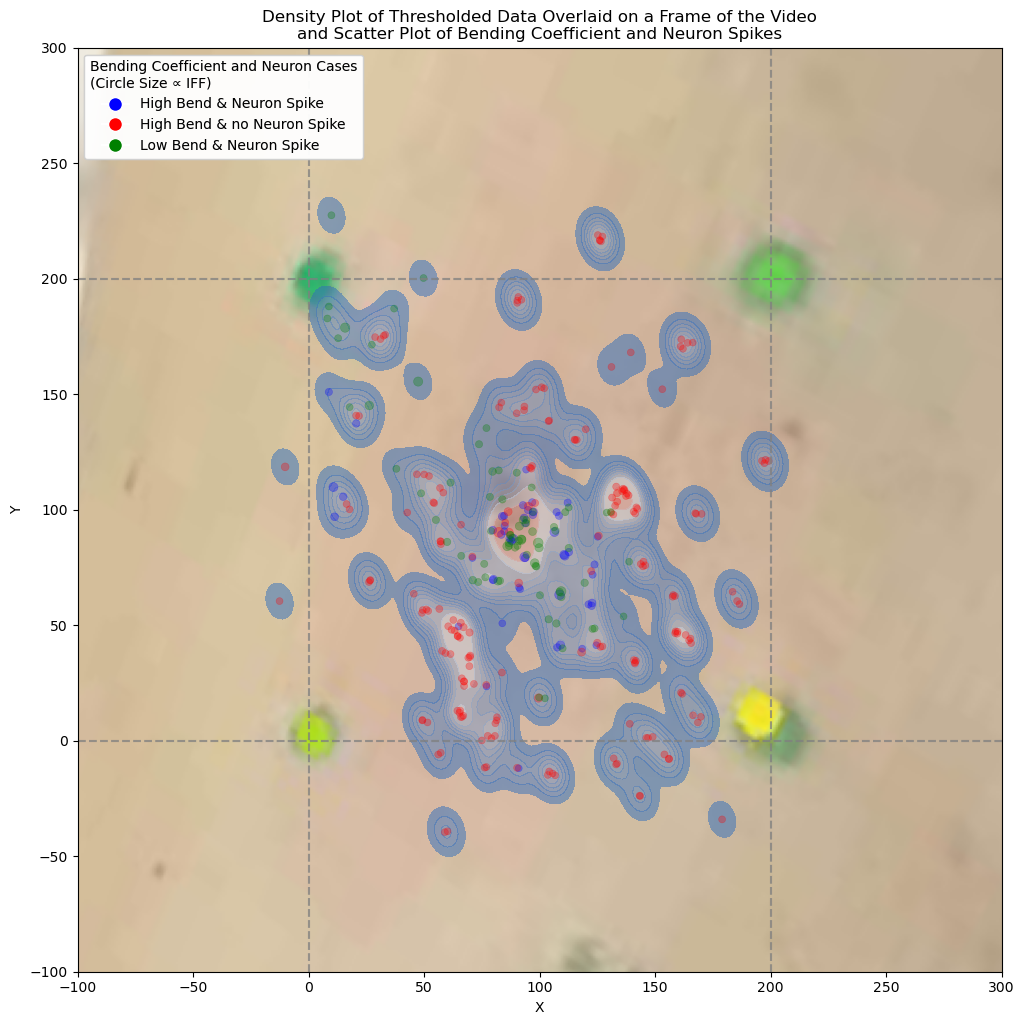

(<Figure size 1200x1200 with 1 Axes>,
 <Axes: title={'center': 'Density Plot of Thresholded Data Overlaid on a Frame of the Video\nand Scatter Plot of Bending Coefficient and Neuron Spikes'}, xlabel='X', ylabel='Y'>)

In [24]:
Plotting.plot_kde_scatter(full_data,
                          "tf_FB2_x", "tf_FB2_y",
                          full_data.dlc.homography_points,
                          size="IFF",
                          title="Density Plot of Thresholded Data Overlaid on a Frame of the Video" +
                                "\nand Scatter Plot of Bending Coefficient and Neuron Spikes",
                          kde=True,
                          scatter=True,
                          # inputs for selecting a specific frame as background
                          frame=True,
                          video_path=video_path,
                          index=index_frame)

In [25]:
Plotting.plot_scroll_over_video(full_data,
                                columns = ["IFF", "Spikes"],
                                video_path = video_path,
                                output_path = "scrolling_plot_3741.mp4")

In [ ]:
full_data.save_cleaned_data(r"C:\Python Programming\LIU\RF_mapping\RF_mapping\post_processing\results\3741\cleaned_data_3741.csv", "csv")
full_data.save_cleaned_data(r"C:\Python Programming\LIU\RF_mapping\RF_mapping\post_processing\results\3741\cleaned_data_3741.xlsx", "xlsx")

Data saved to C:\Python Programming\LIU\RF_mapping\RF_mapping\post_processing\results\3741\merged_data_3741.csv
Data saved to C:\Python Programming\LIU\RF_mapping\RF_mapping\post_processing\results\3741\merged_data_3741.xlsx


In [27]:
full_data.save_full_data(r"C:\Python Programming\LIU\RF_mapping\RF_mapping\post_processing\results\3741\full_data_3741.csv", "csv")
full_data.save_full_data(r"C:\Python Programming\LIU\RF_mapping\RF_mapping\post_processing\results\3741\full_data_3741.xlsx", "xlsx")

Data saved to C:\Python Programming\LIU\RF_mapping\RF_mapping\post_processing\results\3741\full_data_3741.csv
Data saved to C:\Python Programming\LIU\RF_mapping\RF_mapping\post_processing\results\3741\full_data_3741.xlsx
